/tmp/ipykernel_1781109/15079834.py:20: RuntimeWarning: divide by zero encountered in log10
  Z[i, :] = np.log10(np.abs(coeff * (u_vals ** k)))


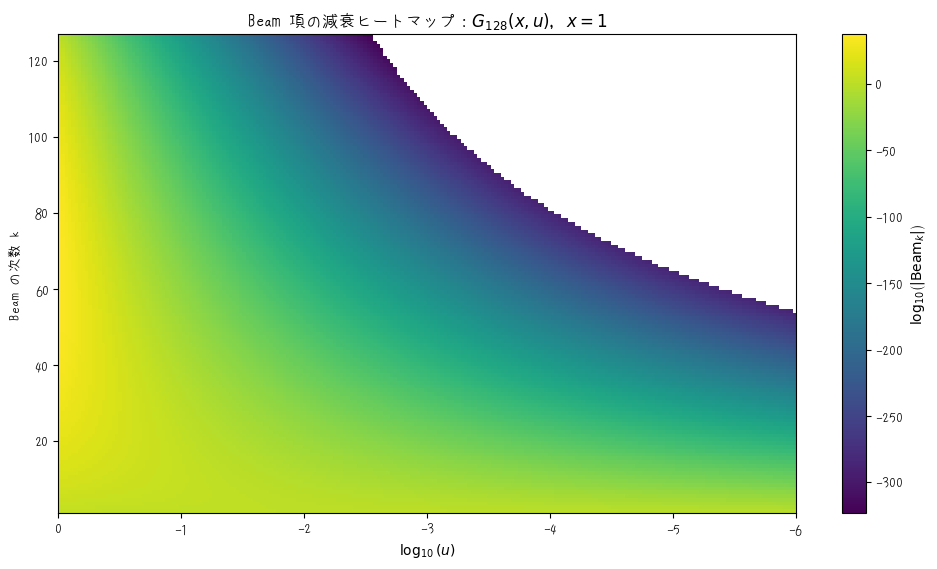

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

#patplotの日本語表示のための設定
plt.rcParams["font.family"] = "kiloji"  # 日本語フォントを指定
plt.rcParams["axes.unicode_minus"] = False  # マイナス記号を正しく表示するための設定

# Parameters for a concrete example of the Beam hierarchy
d = 128  # Dimension of the system (number of variables)
x = 1.0
u_vals = np.logspace(0, -6, 220)  # from 1 down to 1e-6
k_vals = np.arange(1, d)          # Beam_k corresponds to u^k term

# Magnitude of each Beam_k term in G_d(x,u)
# G_d(x,u) = d*x^(d-1) + sum_{k=1}^{d-1} binom(d,k+1) x^(d-1-k) u^k
Z = np.zeros((len(k_vals), len(u_vals)))
for i, k in enumerate(k_vals):
    coeff = comb(d, k + 1) * (x ** (d - 1 - k))
    Z[i, :] = np.log10(np.abs(coeff * (u_vals ** k)))

fig, ax = plt.subplots(figsize=(10, 5.8))
im = ax.imshow(
    Z,
    aspect="auto",
    origin="lower",
    extent=[np.log10(u_vals[0]), np.log10(u_vals[-1]), k_vals[0], k_vals[-1]],
)

ax.set_title(r"Beam 項の減衰ヒートマップ：$G_{%d}(x,u)$, $x=1$" % d)
ax.set_xlabel(r"$\log_{10}(u)$")
ax.set_ylabel("Beam の次数 k")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\log_{10}\!\left(|\mathrm{Beam}_k|\right)$")

plt.tight_layout()
plt.show()


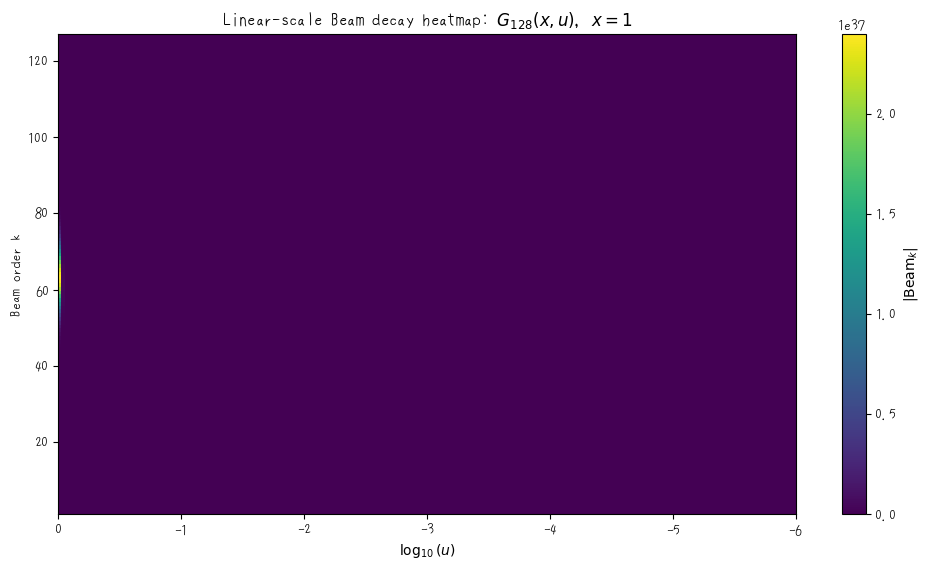

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

# Parameters matching the previous high-degree example
d = 128
x = 1.0
u_vals = np.logspace(0, -6, 220)
k_vals = np.arange(1, d)

# Linear-scale magnitudes of Beam_k in G_d(x,u)
Z = np.zeros((len(k_vals), len(u_vals)))
for i, k in enumerate(k_vals):
    coeff = comb(d, k + 1) * (x ** (d - 1 - k))
    Z[i, :] = np.abs(coeff * (u_vals ** k))

fig, ax = plt.subplots(figsize=(10, 5.8))
im = ax.imshow(
    Z,
    aspect="auto",
    origin="lower",
    extent=[np.log10(u_vals[0]), np.log10(u_vals[-1]), k_vals[0], k_vals[-1]],
)

ax.set_title(r"Linear-scale Beam decay heatmap: $G_{128}(x,u)$, $x=1$")
ax.set_xlabel(r"$\log_{10}(u)$")
ax.set_ylabel("Beam order k")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$|\mathrm{Beam}_k|$")

plt.tight_layout()
plt.show()


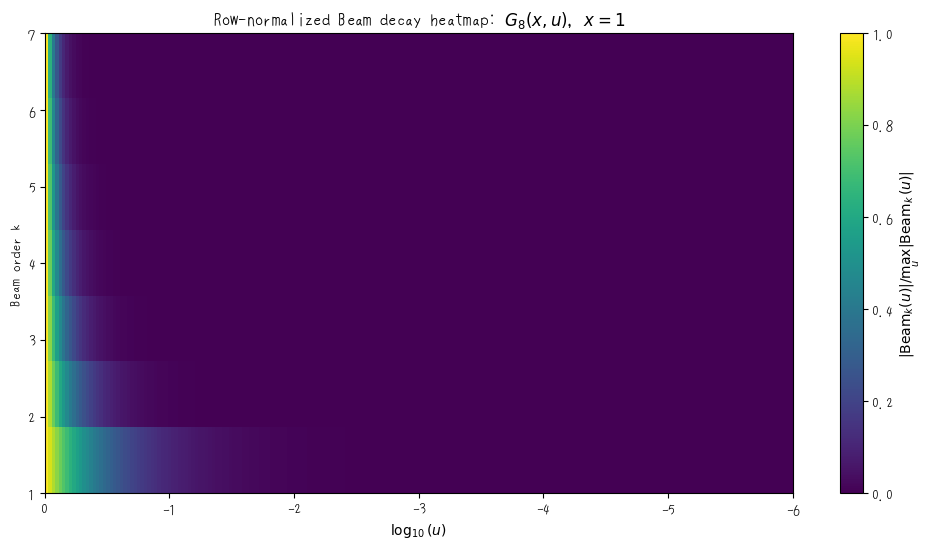

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

# Parameters
d = 8
x = 1.0
u_vals = np.logspace(0, -6, 220)
k_vals = np.arange(1, d)

# Beam magnitudes and row-wise normalization
Z = np.zeros((len(k_vals), len(u_vals)))
for i, k in enumerate(k_vals):
    coeff = comb(d, k + 1) * (x ** (d - 1 - k))
    Z[i, :] = np.abs(coeff * (u_vals ** k))

row_max = Z.max(axis=1, keepdims=True)
Z_norm = np.divide(Z, row_max, out=np.zeros_like(Z), where=row_max > 0)

fig, ax = plt.subplots(figsize=(10, 5.6))
im = ax.imshow(
    Z_norm,
    aspect="auto",
    origin="lower",
    extent=[np.log10(u_vals[0]), np.log10(u_vals[-1]), k_vals[0], k_vals[-1]],
)

ax.set_title(r"Row-normalized Beam decay heatmap: $G_{8}(x,u)$, $x=1$")
ax.set_xlabel(r"$\log_{10}(u)$")
ax.set_ylabel("Beam order k")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$|\mathrm{Beam}_k(u)| / \max_u |\mathrm{Beam}_k(u)|$")

plt.tight_layout()
plt.show()
